In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.linear_model import Perceptron                     # Used for simple linear classification tasks.
from tensorflow.keras.models import Sequential                  # It helps to build a neural network layer-by-layer in keras
from tensorflow.keras.layers import Dense                       # Dense makes the final Prediction
from tensorflow.keras.layers import Conv2D                      # It extracts features
from tensorflow.keras.layers import Flatten                     # It reshapes the structure into 1-D matrix
from tensorflow.keras.layers import MaxPooling2D                # It reduces size
from tensorflow.keras.layers import Dropout                     # It prevents overfitting
from tensorflow.keras.utils import to_categorical               # It converts numeric class labels into one-hot encoded format for training classification model

In [3]:
df=pd.read_csv('mnist_train.csv')
df_test=pd.read_csv('mnist_test.csv')

In [4]:
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df.shape

(60000, 785)

In [6]:
df.columns

Index(['label', '1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8', '1x9',
       ...
       '28x19', '28x20', '28x21', '28x22', '28x23', '28x24', '28x25', '28x26',
       '28x27', '28x28'],
      dtype='object', length=785)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB


In [8]:
df.isnull().sum()

label    0
1x1      0
1x2      0
1x3      0
1x4      0
        ..
28x24    0
28x25    0
28x26    0
28x27    0
28x28    0
Length: 785, dtype: int64

### Preprocessing the Data


In [9]:
X_train = df.drop("label", axis=1).values
y_train = df["label"].values
X_test = df_test.drop("label", axis=1).values
y_test = df_test["label"].values

In [10]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [11]:
X_train_img = X_train.reshape(-1, 28, 28)
X_test_img = X_test.reshape(-1, 28, 28)

In [12]:
X_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(60000, 784), dtype=float32)

In [13]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [14]:
perceptron = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10, activation="softmax")
])

In [15]:
perceptron.compile(optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])

In [16]:
history_percp = perceptron.fit(X_train_img, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_img, y_test_cat), verbose=1)
     

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8172 - loss: 0.7729 - val_accuracy: 0.8825 - val_loss: 0.4780
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 927us/step - accuracy: 0.8812 - loss: 0.4541 - val_accuracy: 0.8935 - val_loss: 0.3992
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 867us/step - accuracy: 0.8914 - loss: 0.4024 - val_accuracy: 0.9009 - val_loss: 0.3671
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 905us/step - accuracy: 0.8975 - loss: 0.3762 - val_accuracy: 0.9063 - val_loss: 0.3478
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 875us/step - accuracy: 0.9012 - loss: 0.3598 - val_accuracy: 0.9084 - val_loss: 0.3361


In [17]:
acc_percp=perceptron.evaluate(X_test_img,y_test_cat,verbose=0)[1]

In [18]:
acc_percp

0.9083999991416931

## ANN layers

In [19]:
ann=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation="relu"),
    Dense(64,activation="relu"),
    Dense(10,activation="softmax")

])

In [20]:
ann.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

In [21]:
history_ann=ann.fit(X_train_img,y_train_cat,epochs=5,batch_size=32,validation_data=(X_test_img,y_test_cat),verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9300 - loss: 0.2390 - val_accuracy: 0.9617 - val_loss: 0.1234
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9689 - loss: 0.1014 - val_accuracy: 0.9738 - val_loss: 0.0834
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9775 - loss: 0.0714 - val_accuracy: 0.9748 - val_loss: 0.0838
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9831 - loss: 0.0536 - val_accuracy: 0.9733 - val_loss: 0.0913
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9861 - loss: 0.0427 - val_accuracy: 0.9772 - val_loss: 0.0791


In [22]:
acc_ann=ann.evaluate(X_test_img,y_test_cat,verbose=0)[1]

In [23]:
acc_ann

0.9771999716758728

## CNN

In [24]:
X_train_cnn=X_train.reshape(-1,28,28,1)
X_test_cnn=X_test.reshape(-1,28,28,1)

In [25]:
cnn=Sequential([
    Conv2D(32,kernel_size=(3,3),activation="relu",input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64,kernel_size=(3,3),activation="relu"),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128,activation="relu"),
    Dropout(0.5),
    Dense(10,activation="softmax")
])

In [26]:
cnn.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

In [27]:
history_cnn=cnn.fit(X_train_cnn,y_train_cat,epochs=5,batch_size=32,validation_data=(X_test_cnn,y_test_cat),verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9362 - loss: 0.2113 - val_accuracy: 0.9842 - val_loss: 0.0475
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9765 - loss: 0.0780 - val_accuracy: 0.9869 - val_loss: 0.0371
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9818 - loss: 0.0602 - val_accuracy: 0.9903 - val_loss: 0.0287
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9859 - loss: 0.0470 - val_accuracy: 0.9908 - val_loss: 0.0282
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9885 - loss: 0.0396 - val_accuracy: 0.9903 - val_loss: 0.0271


In [28]:
acc_cnn=cnn.evaluate(X_test_cnn,y_test_cat,verbose=0)[1]

In [29]:
acc_cnn

0.9902999997138977

In [30]:
def plot_training(history,title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'],label="Train")
    plt.plot(history.history['val_accuracy'],label="val")
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'],label="Train")
    plt.plot(history.history['val_loss'],label="val")
    plt.title(f"{title} loss")
    plt.legend()
    plt.show()

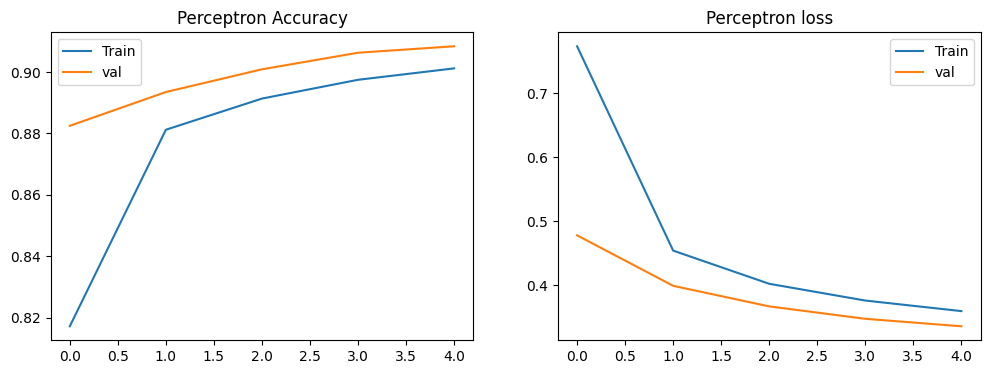

In [31]:
plot_training(history_percp,"Perceptron")

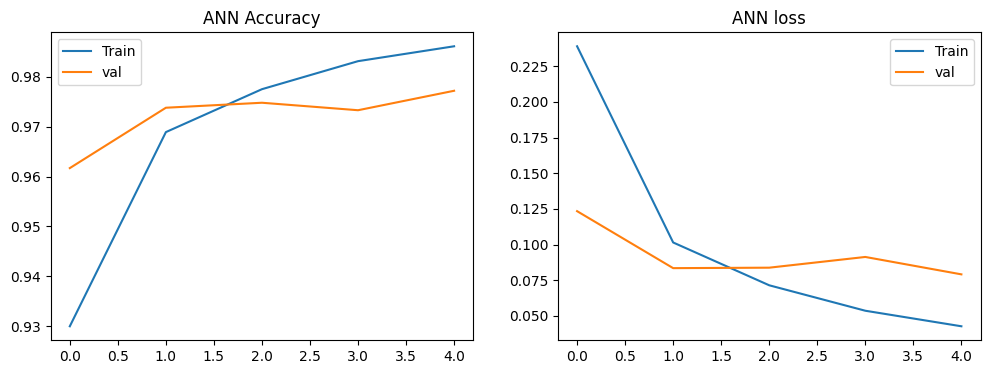

In [32]:
plot_training(history_ann,"ANN")

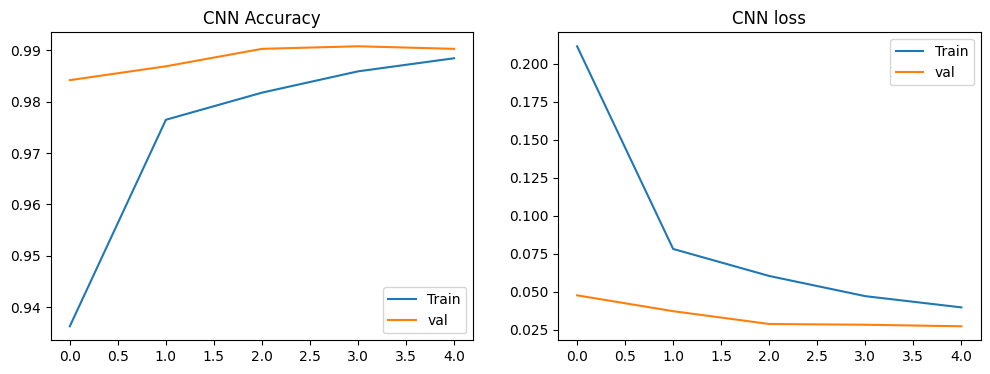

In [33]:
plot_training(history_cnn,"CNN")

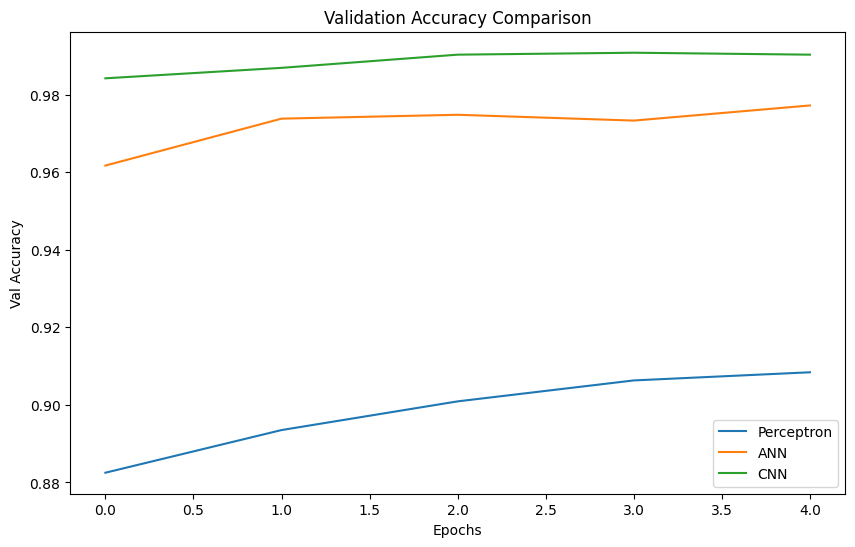

In [34]:
plt.figure(figsize=(10,6))
plt.plot(history_percp.history['val_accuracy'],label="Perceptron")
plt.plot(history_ann.history['val_accuracy'],label="ANN")
plt.plot(history_cnn.history['val_accuracy'],label="CNN")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()

In [35]:
def show_side_by_side(models,model_names,X,X_cnn,y_true,n=5):
    idxs=np.random.choice(len(X),n,replace=False)
    plt.figure(figsize=[15,6])
    for i,idx in enumerate(idxs):
        plt.subplot(2,n,i+1)
        plt.imshow(X[idx].reshape(28,28),cmap="grey")
        plt.axis("off")
        plt.title(f"True:{y_true[idx]}")
        preds=[np.argmax(model.predict(X_cnn[idx].reshape(1,28,28) 
        if name=="CNN" 
        else X[idx].reshape(1,28,28)))
            for model,name in zip(models,model_names)]
        plt.subplot(2,n,n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{n}:{p}" for n,p in zip(model_names,preds)))
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


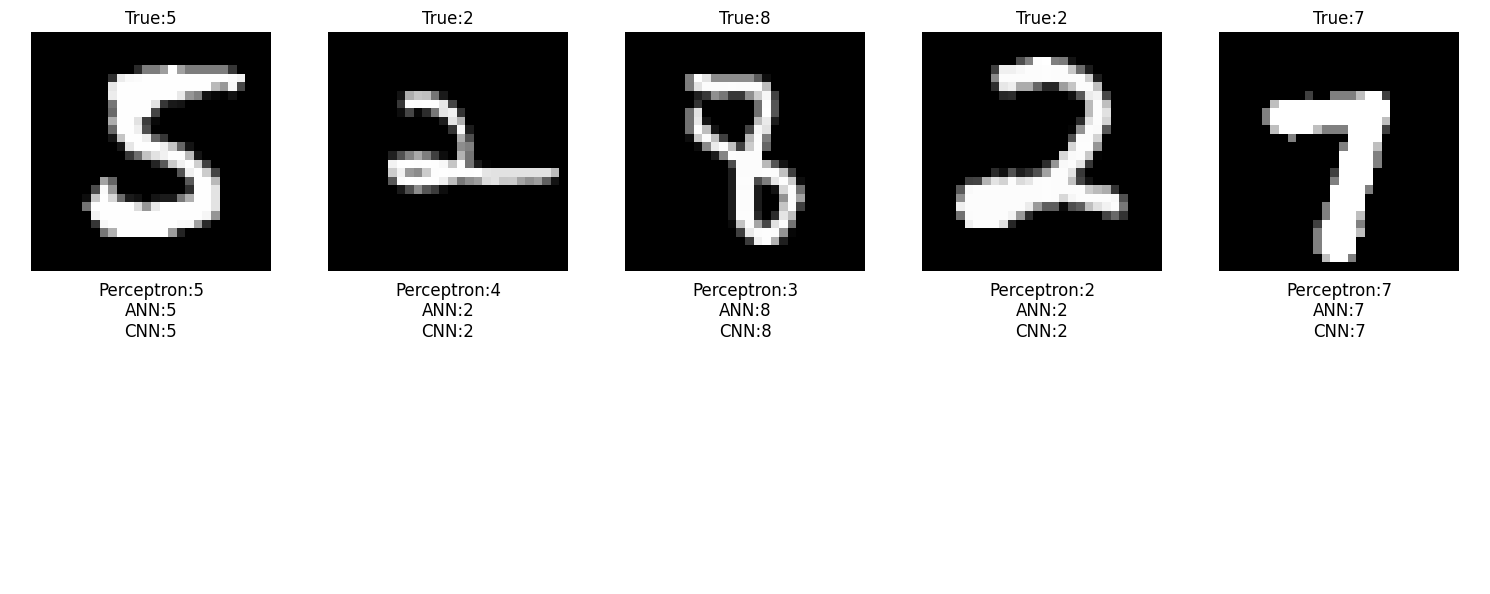

In [36]:
show_side_by_side([perceptron,ann,cnn],["Perceptron","ANN","CNN"],X_test_img,X_test_cnn,y_test,5)

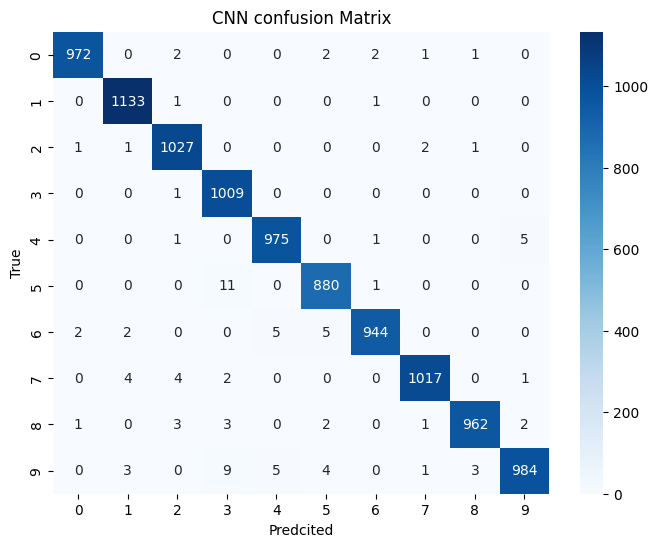

In [37]:
y_pred_cnn = np.argmax(cnn.predict_on_batch(X_test_cnn), axis=1)
cm=confusion_matrix(y_test,y_pred_cnn)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.title("CNN confusion Matrix")
plt.xlabel("Predcited")
plt.ylabel("True")
plt.show()

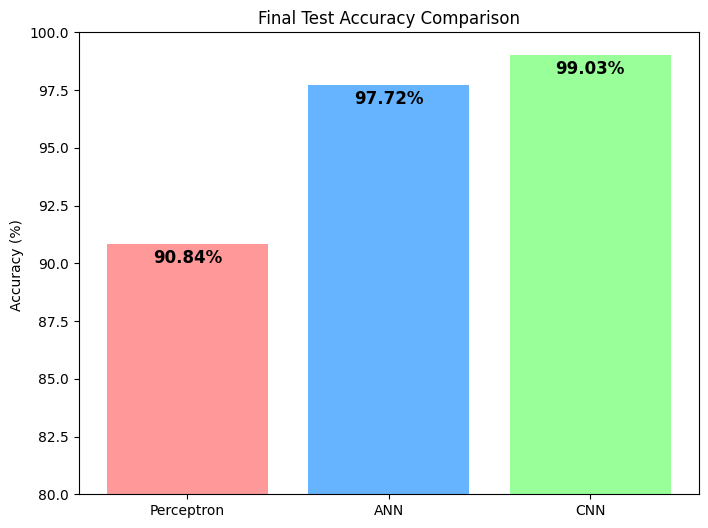

In [38]:
final_accs=[acc_percp*100,acc_ann*100,acc_cnn*100]
models=["Perceptron","ANN","CNN"]
plt.figure(figsize=(8,6))
bars=plt.bar(models,final_accs,color=['#ff9999','#66b3ff','#99ff99'])
plt.title("Final Test Accuracy Comparison")
plt.ylabel("Accuracy (%) ")
for bar,acc in zip(bars,final_accs):
    plt.text(bar.get_x()+bar.get_width()/2,bar.get_height()-1,f"{acc:.2f}%",ha='center', va='bottom',fontsize=12,fontweight='bold')

plt.ylim(80,100)
plt.show()